# Bot-IoT Version2 TOP10：分開分類 + 隨機森林independent vs Chained

本筆記本分成上下兩段：
1. 上半段：直接使用原始資料做隨機森林分類（不特別平衡）(Independent)
2. 下半段：直接使用原始資料做隨機森林分類（不特別平衡）(Chain)

每一種分類法都會獨立執行，並在執行前用中文說明模型用途與參數設定。

## 流程總覽

前置作業 -> 各種分類法（原始資料） -> 視覺化結果1 -> 各種分類法（平衡資料） -> 視覺化結果2

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## 參數與切割設定（報告可直接引用）

- 資料來源：`Dataset_for_train_and_test` 中官方 Training / Testing 檔
- 特徵：論文 TOP10（10 個數值特徵）
- 目標：`attack`、`category`、`subcategory`
- 訓練/驗證切割：從 Training 檔再切出 `25% validation`，使用三標籤組合分層抽樣（避免分布偏移）
- 測試：最後使用官方 Testing 檔做最終評估

In [2]:
RANDOM_STATE = 42
TRAIN_PATH = "Dataset_for_train_and_test/UNSW_2018_IoT_Botnet_Final_10_best_Training.csv"
TEST_PATH = "Dataset_for_train_and_test/UNSW_2018_IoT_Botnet_Final_10_best_Testing.csv"

FEATURE_COLUMNS = [
    "seq",
    "stddev",
    "N_IN_Conn_P_SrcIP",
    "min",
    "state_number",
    "mean",
    "N_IN_Conn_P_DstIP",
    "drate",
    "srate",
    "max",
]
TARGET_COLUMNS = ["attack", "category", "subcategory"]

VALID_SIZE = 0.25
BALANCE_METHOD = "smote"  # smote 或 random_over

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (2934817, 13)
Test shape : (733705, 13)


In [4]:
X_all = train_df[FEATURE_COLUMNS].copy()
y_all = train_df[TARGET_COLUMNS].copy()
X_test_official = test_df[FEATURE_COLUMNS].copy()
y_test_official = test_df[TARGET_COLUMNS].copy()

label_encoders = {}
for target_col in ["category", "subcategory"]:
    le = LabelEncoder()
    y_all[target_col] = le.fit_transform(y_all[target_col])
    y_test_official[target_col] = le.transform(y_test_official[target_col])
    label_encoders[target_col] = le

stratify_key = (
    y_all["attack"].astype(str) + "_" +
    y_all["category"].astype(str) + "_" +
    y_all["subcategory"].astype(str)
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all,
    y_all,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_key
)


scaler_val = StandardScaler()
X_train_scaled = scaler_val.fit_transform(X_train)
X_valid_scaled = scaler_val.transform(X_valid)

X_test_official_scaled = scaler_val.transform(X_test_official)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("分層切割 key 範例:", stratify_key.iloc[0])

X_train: (2201112, 10) X_valid: (733705, 10)
分層切割 key 範例: 1_0_6


In [5]:
for col in TARGET_COLUMNS:
    print(f"\n{col} distribution (train split):")
    print(y_train[col].value_counts(normalize=True).head(10))


attack distribution (train split):
attack
1    0.99987
0    0.00013
Name: proportion, dtype: float64

category distribution (train split):
category
0    0.525177
1    0.449844
3    0.024827
2    0.000130
4    0.000022
Name: proportion, dtype: float64

subcategory distribution (train split):
subcategory
7    0.540062
6    0.434284
5    0.019944
4    0.004883
1    0.000674
3    0.000130
2    0.000020
0    0.000002
Name: proportion, dtype: float64


## 共用函式（訓練、評估、視覺化）(Independent)

In [6]:
class IndependentMultiTargetClassifier:
    def __init__(self, attack_model, category_model, subcategory_model):
        self.attack_model = attack_model
        self.category_model = category_model
        self.subcategory_model = subcategory_model

    def fit(self, X, y):
        # 三個分類器都只看原始特徵 X
        self.attack_model.fit(X, y["attack"])
        self.category_model.fit(X, y["category"])
        self.subcategory_model.fit(X, y["subcategory"])
        return self

    def predict(self, X):
        # 三個分類器都只看原始特徵 X，互不影響
        pred_attack      = self.attack_model.predict(X)
        pred_category    = self.category_model.predict(X)
        pred_subcategory = self.subcategory_model.predict(X)
        return pd.DataFrame({
            "attack":      pred_attack,
            "category":    pred_category,
            "subcategory": pred_subcategory,
        })
def build_independent_model(model_name, seed=RANDOM_STATE):
    n_category = y_all["category"].nunique()
    n_subcategory = y_all["subcategory"].nunique()

    if model_name == "RandomForest":
        return IndependentMultiTargetClassifier(
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
        )

    if model_name == "NaiveBayes":
        return IndependentMultiTargetClassifier(GaussianNB(), GaussianNB(), GaussianNB())

    if model_name == "DecisionTreeEntropy":
        return IndependentMultiTargetClassifier(
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
        )

    if model_name == "DecisionTreeGini":
        return IndependentMultiTargetClassifier(
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
        )

    if model_name == "XGBoost":
        return IndependentMultiTargetClassifier(
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="logloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_category,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_subcategory,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
        )

    raise ValueError(f"Unknown model: {model_name}")

def evaluate_predictions(y_true, y_pred, target_col):
    y_t = y_true[target_col]
    y_p = y_pred[target_col]
    return {
        "target": target_col,
        "accuracy": accuracy_score(y_t, y_p),
        "balanced_accuracy": balanced_accuracy_score(y_t, y_p),
        "macro_f1": f1_score(y_t, y_p, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_t, y_p, average="weighted", zero_division=0),
    }

def run_independent_model(model_name, X_fit, y_fit, X_eval, y_eval):
    import time
    model = build_independent_model(model_name)

    # 三個標籤分開計時
    t0 = time.time()
    model.attack_model.fit(X_fit, y_fit["attack"])
    time_attack = round(time.time() - t0, 2)

    t0 = time.time()
    model.category_model.fit(X_fit, y_fit["category"])
    time_category = round(time.time() - t0, 2)

    t0 = time.time()
    model.subcategory_model.fit(X_fit, y_fit["subcategory"])
    time_subcategory = round(time.time() - t0, 2)

    time_map = {
        "attack": time_attack,
        "category": time_category,
        "subcategory": time_subcategory,
    }

    preds = model.predict(X_eval)

    rows = []
    for target_col in TARGET_COLUMNS:
        row = evaluate_predictions(y_eval, preds, target_col)
        row["model"] = model_name
        row["train_time_sec"] = time_map[target_col]
        rows.append(row)

    return model, preds, pd.DataFrame(rows)


def decode_labels_if_needed(values, target_col):
    if target_col in label_encoders:
        return label_encoders[target_col].inverse_transform(values)
    return values

def show_confusion_matrices(result_store, y_true, section_title):
    metrics_df = pd.concat([v["metrics"] for v in result_store.values()], ignore_index=True)

    best_map = {}
    for target_col in TARGET_COLUMNS:
        picked = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False).iloc[0]
        best_map[target_col] = picked["model"]

    print(f"{section_title} 各目標最佳模型：", best_map)

    for target_col in TARGET_COLUMNS:
        best_model = best_map[target_col]
        y_t = y_true[target_col].to_numpy()
        y_p = result_store[best_model]["preds"][target_col].to_numpy()

        labels = np.unique(np.concatenate([y_t, y_p]))
        cm = confusion_matrix(y_t, y_p, labels=labels)

        tick_labels = decode_labels_if_needed(labels, target_col)

        plt.figure(figsize=(7, 5))
        sns.heatmap(
            cm,
            cmap="Blues",
            annot=True,
            fmt="d",
            linewidths=0.5,
            linecolor="gray"
        )
        plt.title(f"{section_title} | {target_col} | Best: {best_model}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=45, ha="right")
        plt.yticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=0)
        plt.tight_layout()
        plt.show()

def show_metric_bars(metrics_df, title_prefix):
    for target_col in TARGET_COLUMNS:
        sub_df = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False)
        plt.figure(figsize=(8, 4))
        sns.barplot(data=sub_df, x="model", y="macro_f1", color="#4E79A7")
        plt.ylim(0, 1)
        plt.title(f"{title_prefix} | {target_col} Macro-F1")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

def build_attack_model(model_name, seed=RANDOM_STATE):
    if model_name == "RandomForest":
        return RandomForestClassifier(max_depth=8, n_estimators=120, random_state=seed, n_jobs=-1)
    if model_name == "NaiveBayes":
        return GaussianNB()
    if model_name == "DecisionTreeEntropy":
        return DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=seed)
    if model_name == "DecisionTreeGini":
        return DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=seed)
    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            n_estimators=120,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")

def run_attack_cv(X, y_attack, model_names, folds=5, sample_size=120000):
    sample_size = min(sample_size, len(y_attack))
    idx = np.random.RandomState(RANDOM_STATE).choice(len(y_attack), size=sample_size, replace=False)
    X_sub = X[idx]
    y_sub = y_attack.iloc[idx].to_numpy()

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for name in model_names:
        est = build_attack_model(name)
        scores = cross_validate(
            est,
            X_sub,
            y_sub,
            cv=skf,
            scoring={
                "acc": "accuracy",
                "bacc": "balanced_accuracy",
                "f1_macro": "f1_macro",
            },
            n_jobs=1,
            return_train_score=False,
        )

        rows.append({
            "model": name,
            "folds": folds,
            "sample_size": sample_size,
            "cv_accuracy_mean": scores["test_acc"].mean(),
            "cv_balanced_accuracy_mean": scores["test_bacc"].mean(),
            "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        })

    return pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)

# 上半部：原始資料（不做 Data Balance）(Independent)

這一段先建立基準結果，模擬『不考慮資料平衡』的傳統分類流程。且樹的預測之間獨立
- X -> [attack]
- X -> [category_model]
- X -> [subcategory]

### 分類法 1：Random Forest
- 用途：透過多棵樹集成，降低單一決策樹過擬合風險
- 參數：`max_depth=[10,10,10]`、`n_estimators=120`、`random_state=42`

In [7]:
independent_results = {}
independent_test_results = {}

In [8]:
rf_model, rf_preds, rf_metrics = run_independent_model("RandomForest", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["RandomForest"] = {"model": rf_model, "preds": rf_preds, "metrics": rf_metrics}
independent_test_results["RandomForest"] = {"model": rf_model, "preds": rf_model.predict(X_test_official_scaled), "metrics": None}
rf_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999965,0.869791,0.922610,0.999962,RandomForest,107.03
1,category,0.994769,0.953135,0.971814,0.994768,RandomForest,129.98
2,subcategory,0.997693,0.823267,0.869148,0.997467,RandomForest,112.43


### 分類法 2：Naive Bayes
- 用途：速度快、可做機率式分類基準
- 參數：`GaussianNB()`（使用預設參數）

In [9]:
nb_model, nb_preds, nb_metrics = run_independent_model("NaiveBayes", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["NaiveBayes"] = {"model": nb_model, "preds": nb_preds, "metrics": nb_metrics}
independent_test_results["NaiveBayes"] = {"model": nb_model, "preds": nb_model.predict(X_test_official_scaled), "metrics": None}  
nb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.996091,0.940761,0.527000,0.997918,NaiveBayes,0.75
1,category,0.707018,0.530434,0.454853,0.681834,NaiveBayes,0.83
2,subcategory,0.978966,0.642225,0.463279,0.975256,NaiveBayes,0.86


### 分類法 3：Decision Tree (Entropy)
- 用途：資訊增益（Entropy）切分規則
- 參數：`criterion=entropy`、`max_depth=[8,10,12]`

In [10]:
dt_e_model, dt_e_preds, dt_e_metrics = run_independent_model("DecisionTreeEntropy", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["DecisionTreeEntropy"] = {"model": dt_e_model, "preds": dt_e_preds, "metrics": dt_e_metrics}
independent_test_results["DecisionTreeEntropy"] = {"model": dt_e_model, "preds": dt_e_model.predict(X_test_official_scaled), "metrics": None}
dt_e_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999992,0.979165,0.984208,0.999992,DecisionTreeEntropy,6.96
1,category,0.989678,0.959693,0.971546,0.989685,DecisionTreeEntropy,28.46
2,subcategory,0.998099,0.947347,0.949614,0.998073,DecisionTreeEntropy,23.04


### 分類法 4：Decision Tree (Gini)
- 用途：Gini impurity 切分規則
- 參數：`criterion=gini`、`max_depth=[8,10,12]`

In [11]:
dt_g_model, dt_g_preds, dt_g_metrics = run_independent_model("DecisionTreeGini", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["DecisionTreeGini"] = {"model": dt_g_model, "preds": dt_g_preds, "metrics": dt_g_metrics}
independent_test_results["DecisionTreeGini"] = {"model": dt_g_model, "preds": dt_g_model.predict(X_test_official_scaled), "metrics": None}
dt_g_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999956,0.874995,0.909080,0.999954,DecisionTreeGini,16.13
1,category,0.989240,0.951569,0.949491,0.989239,DecisionTreeGini,31.14
2,subcategory,0.998276,0.936301,0.906104,0.998219,DecisionTreeGini,21.44


### 分類法 5：XGBoost
- 用途：梯度提升樹，通常在結構化資料有較好表現
- 參數：`n_estimators=150`、`max_depth=6`、`learning_rate=0.08`、`subsample=0.8`、`colsample_bytree=0.8`

In [12]:
xgb_model, xgb_preds, xgb_metrics = run_independent_model("XGBoost", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["XGBoost"] = {"model": xgb_model, "preds": xgb_preds, "metrics": xgb_metrics}
independent_test_results["XGBoost"] = {"model": xgb_model, "preds": xgb_model.predict(X_test_official_scaled), "metrics": None}
xgb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999990,0.968749,0.981281,0.999990,XGBoost,15.32
1,category,0.998264,0.975505,0.985928,0.998264,XGBoost,108.86
2,subcategory,0.998672,0.968863,0.975262,0.998648,XGBoost,166.34


### 原始資料結果整理 + 視覺化結果1
- 顯示各模型指標表
- 畫出 Macro-F1 條圖
- 顯示每個目標最佳模型的混淆矩陣

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
6,attack,0.999992,0.979165,0.984208,0.999992,DecisionTreeEntropy,6.96
12,attack,0.999990,0.968749,0.981281,0.999990,XGBoost,15.32
0,attack,0.999965,0.869791,0.922610,0.999962,RandomForest,107.03
9,attack,0.999956,0.874995,0.909080,0.999954,DecisionTreeGini,16.13
3,attack,0.996091,0.940761,0.527000,0.997918,NaiveBayes,0.75
13,category,0.998264,0.975505,0.985928,0.998264,XGBoost,108.86
1,category,0.994769,0.953135,0.971814,0.994768,RandomForest,129.98
7,category,0.989678,0.959693,0.971546,0.989685,DecisionTreeEntropy,28.46
10,category,0.989240,0.951569,0.949491,0.989239,DecisionTreeGini,31.14
4,category,0.707018,0.530434,0.454853,0.681834,NaiveBayes,0.83


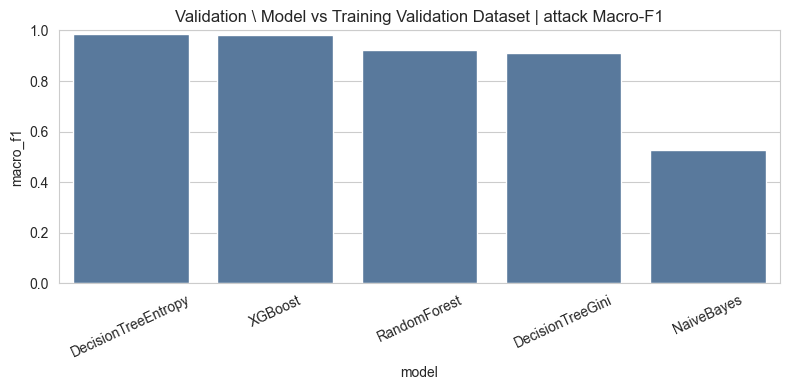

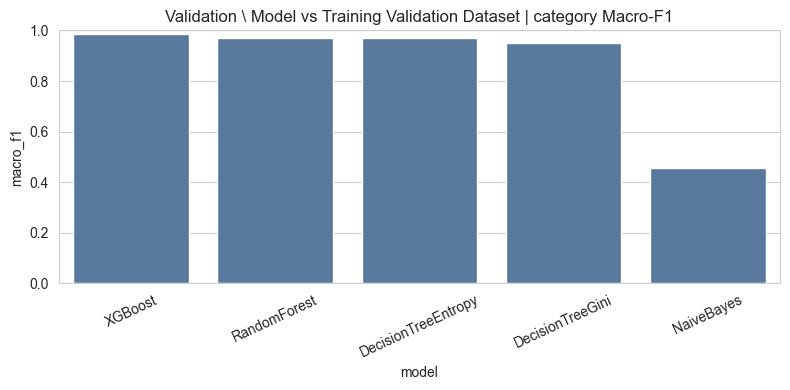

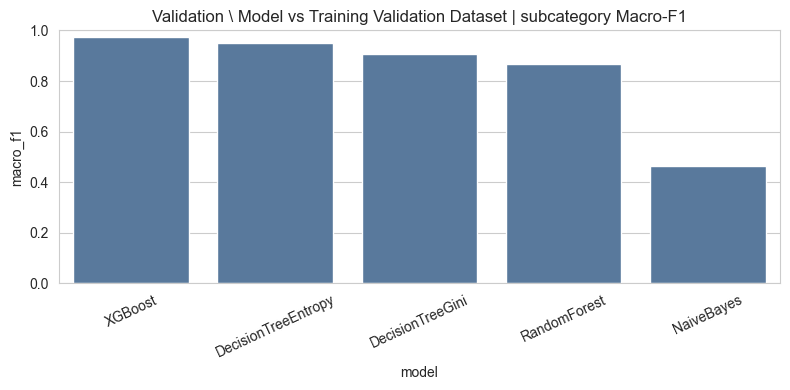

Validation \ Model vs Training Validation Dataset 各目標最佳模型： {'attack': 'DecisionTreeEntropy', 'category': 'XGBoost', 'subcategory': 'XGBoost'}


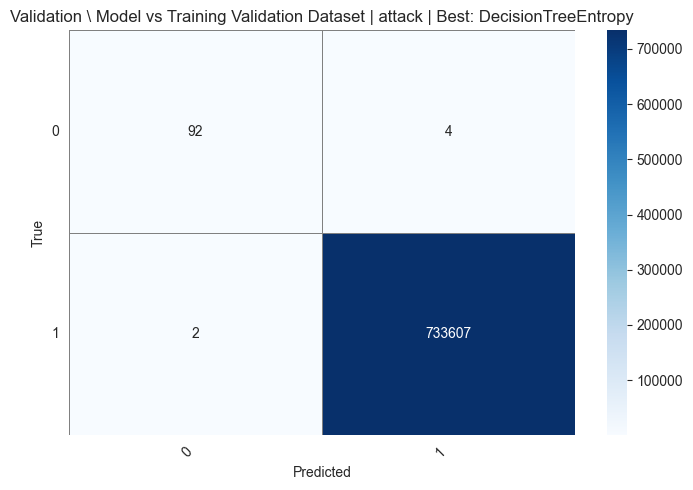

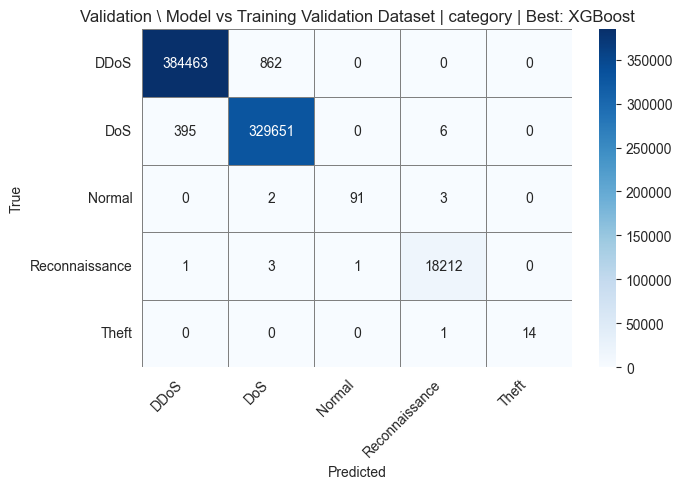

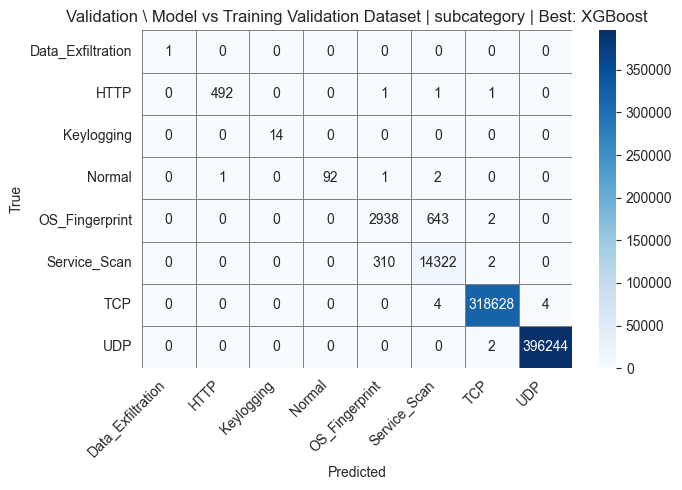

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model
6,attack,0.999997,0.999999,0.994791,0.999997,DecisionTreeEntropy
12,attack,0.999993,0.984209,0.986771,0.999993,XGBoost
9,attack,0.999967,0.936834,0.936834,0.999967,DecisionTreeGini
0,attack,0.999970,0.889473,0.935287,0.999968,RandomForest
3,attack,0.996281,0.956040,0.529037,0.998015,NaiveBayes
13,category,0.998246,0.994991,0.989943,0.998246,XGBoost
1,category,0.994773,0.953647,0.974112,0.994772,RandomForest
7,category,0.989552,0.964286,0.968301,0.989558,DecisionTreeEntropy
10,category,0.989054,0.927967,0.942276,0.989053,DecisionTreeGini
4,category,0.706317,0.540982,0.452647,0.680878,NaiveBayes


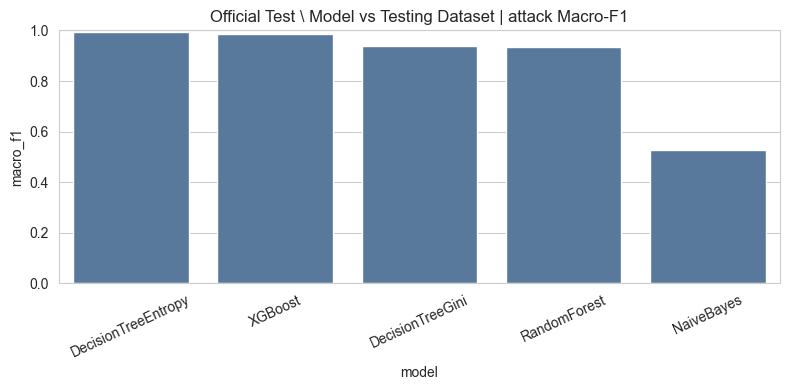

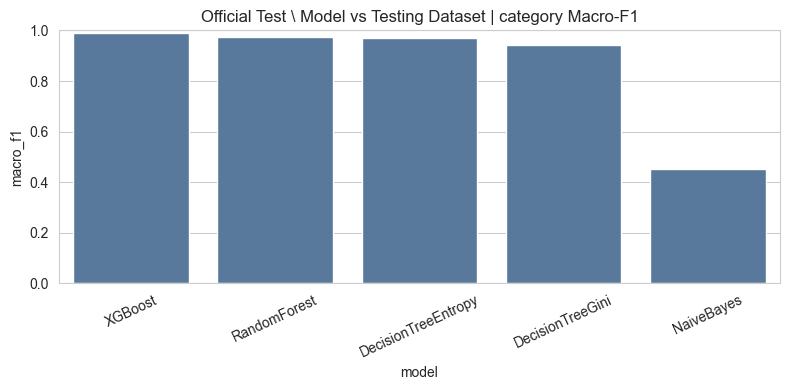

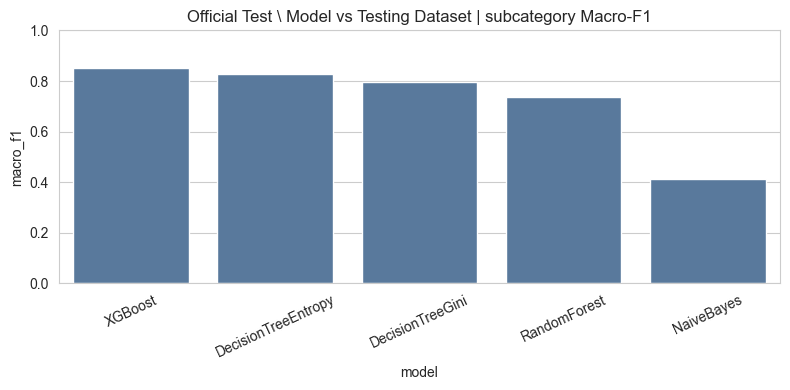

Official Test \ Model vs Testing Dataset 各目標最佳模型： {'attack': 'DecisionTreeEntropy', 'category': 'XGBoost', 'subcategory': 'XGBoost'}


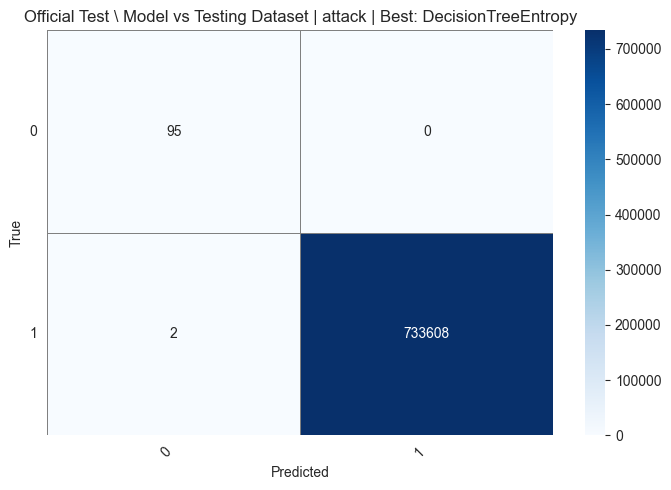

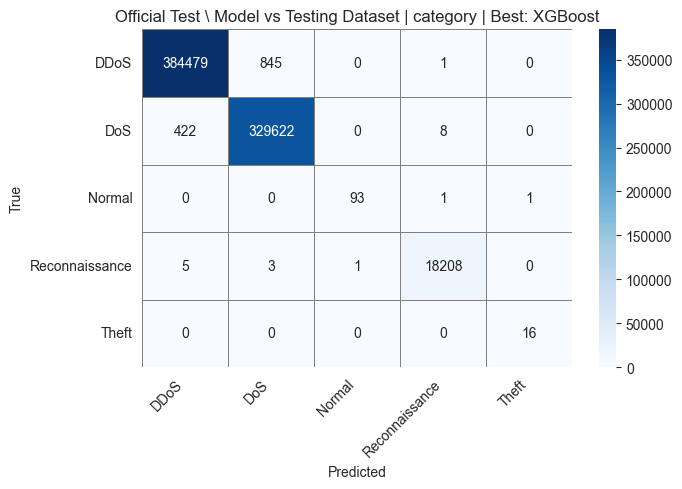

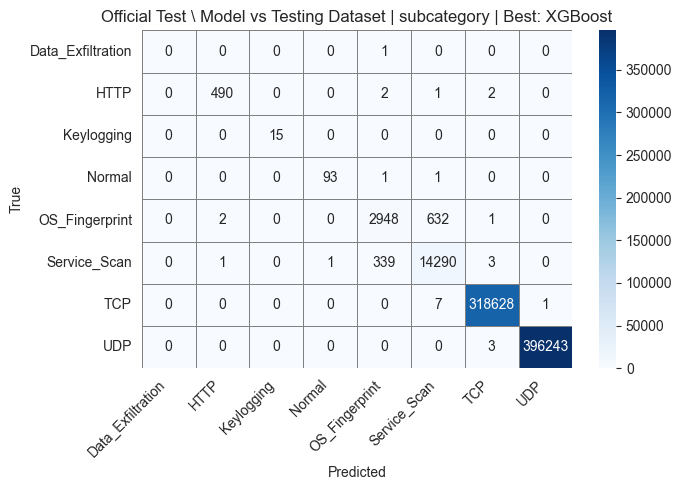

,target,model,validation_macro_f1,test_macro_f1,差距
6,attack,DecisionTreeEntropy,0.984208,0.994791,-0.0106
9,attack,DecisionTreeGini,0.909080,0.936834,-0.0278
3,attack,NaiveBayes,0.527000,0.529037,-0.0020
0,attack,RandomForest,0.922610,0.935287,-0.0127
12,attack,XGBoost,0.981281,0.986771,-0.0055
7,category,DecisionTreeEntropy,0.971546,0.968301,0.0032
10,category,DecisionTreeGini,0.949491,0.942276,0.0072
4,category,NaiveBayes,0.454853,0.452647,0.0022
1,category,RandomForest,0.971814,0.974112,-0.0023
13,category,XGBoost,0.985928,0.989943,-0.0040


In [13]:
unbalanced_metrics_df = pd.concat([v["metrics"] for v in independent_results.values()], ignore_index=True)
display(unbalanced_metrics_df.sort_values(["target", "macro_f1"], ascending=[True, False]))

show_metric_bars(unbalanced_metrics_df, "Validation \ Model vs Training Validation Dataset")
show_confusion_matrices(independent_results, y_valid, "Validation \ Model vs Training Validation Dataset")

for name, v in independent_test_results.items():
    preds = v["preds"]
    rows = []
    for target_col in TARGET_COLUMNS:
        row = evaluate_predictions(y_test_official, pd.DataFrame(preds) if not isinstance(preds, pd.DataFrame) else preds, target_col)
        row["model"] = name
        rows.append(row)
    independent_test_results[name]["metrics"] = pd.DataFrame(rows)

test_metrics_df = pd.concat([v["metrics"] for v in independent_test_results.values()], ignore_index=True)
display(test_metrics_df.sort_values(["target", "macro_f1"], ascending=[True, False]))

show_metric_bars(test_metrics_df, "Official Test \ Model vs Testing Dataset")
show_confusion_matrices(independent_test_results, y_test_official, "Official Test \ Model vs Testing Dataset")

# 對比表
comparison = pd.merge(
    unbalanced_metrics_df[["target","model","macro_f1"]].rename(columns={"macro_f1":"validation_macro_f1"}),
    test_metrics_df[["target","model","macro_f1"]].rename(columns={"macro_f1":"test_macro_f1"}),
    on=["target","model"]
)
comparison["差距"] = (comparison["validation_macro_f1"] - comparison["test_macro_f1"]).round(4)
display(comparison.sort_values(["target","model"]))

# 下半部：原始資料（不做 Data Balance）(Chain)

這一段先建立基準結果，模擬『不考慮資料平衡』的傳統分類流程。且樹的預測之間獨立
- X -> predict[attack]
- X + predict[attack] -> predict[category_model]
- X + predict[attack] + predict[category_model] -> [subcategory]

## 共用函式（訓練、評估、視覺化）

In [14]:
class ChainedMultiTargetClassifier:
    def __init__(self, attack_model, category_model, subcategory_model):
        self.attack_model = attack_model
        self.category_model = category_model
        self.subcategory_model = subcategory_model

    def fit(self, X, y):
        self.attack_model.fit(X, y["attack"])
        category_features = np.concatenate([X, y[["attack"]].to_numpy()], axis=1)
        self.category_model.fit(category_features, y["category"])
        subcategory_features = np.concatenate([category_features, y[["category"]].to_numpy()], axis=1)
        self.subcategory_model.fit(subcategory_features, y["subcategory"])
        return self

    def predict(self, X):
        pred_attack = self.attack_model.predict(X)
        category_features = np.concatenate([X, pred_attack.reshape(-1, 1)], axis=1)
        pred_category = self.category_model.predict(category_features)
        subcategory_features = np.concatenate([category_features, pred_category.reshape(-1, 1)], axis=1)
        pred_subcategory = self.subcategory_model.predict(subcategory_features)
        return pd.DataFrame({
            "attack": pred_attack,
            "category": pred_category,
            "subcategory": pred_subcategory,
        })

def build_chain_model(model_name, seed=RANDOM_STATE):
    n_category = y_all["category"].nunique()
    n_subcategory = y_all["subcategory"].nunique()

    if model_name == "RandomForest":
        return ChainedMultiTargetClassifier(
            RandomForestClassifier(max_depth=8, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=12, n_estimators=120, random_state=seed, n_jobs=-1),
        )

    if model_name == "NaiveBayes":
        return ChainedMultiTargetClassifier(GaussianNB(), GaussianNB(), GaussianNB())

    if model_name == "DecisionTreeEntropy":
        return ChainedMultiTargetClassifier(
            DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=12, random_state=seed),
        )

    if model_name == "DecisionTreeGini":
        return ChainedMultiTargetClassifier(
            DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=12, random_state=seed),
        )

    if model_name == "XGBoost":
        return ChainedMultiTargetClassifier(
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="logloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_category,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_subcategory,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
        )

    raise ValueError(f"Unknown model: {model_name}")

def evaluate_predictions(y_true, y_pred, target_col):
    y_t = y_true[target_col]
    y_p = y_pred[target_col]
    return {
        "target": target_col,
        "accuracy": accuracy_score(y_t, y_p),
        "balanced_accuracy": balanced_accuracy_score(y_t, y_p),
        "macro_f1": f1_score(y_t, y_p, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_t, y_p, average="weighted", zero_division=0),
    }

def run_chain_model(model_name, X_fit, y_fit, X_eval, y_eval):
    import time
    model = build_chain_model(model_name)

    # Chain 模型依序訓練，分開計時
    t0 = time.time()
    model.attack_model.fit(X_fit, y_fit["attack"])
    time_attack = round(time.time() - t0, 2)

    t0 = time.time()
    category_features = np.concatenate([X_fit, y_fit[["attack"]].to_numpy()], axis=1)
    model.category_model.fit(category_features, y_fit["category"])
    time_category = round(time.time() - t0, 2)

    t0 = time.time()
    subcategory_features = np.concatenate([category_features, y_fit[["category"]].to_numpy()], axis=1)
    model.subcategory_model.fit(subcategory_features, y_fit["subcategory"])
    time_subcategory = round(time.time() - t0, 2)

    time_map = {
        "attack": time_attack,
        "category": time_category,
        "subcategory": time_subcategory,
    }

    preds = model.predict(X_eval)

    rows = []
    for target_col in TARGET_COLUMNS:
        row = evaluate_predictions(y_eval, preds, target_col)
        row["model"] = model_name
        row["train_time_sec"] = time_map[target_col]
        rows.append(row)

    return model, preds, pd.DataFrame(rows)

def decode_labels_if_needed(values, target_col):
    if target_col in label_encoders:
        return label_encoders[target_col].inverse_transform(values)
    return values

def show_confusion_matrices(result_store, y_true, section_title):
    metrics_df = pd.concat([v["metrics"] for v in result_store.values()], ignore_index=True)

    best_map = {}
    for target_col in TARGET_COLUMNS:
        picked = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False).iloc[0]
        best_map[target_col] = picked["model"]

    print(f"{section_title} 各目標最佳模型：", best_map)

    for target_col in TARGET_COLUMNS:
        best_model = best_map[target_col]
        y_t = y_true[target_col].to_numpy()
        y_p = result_store[best_model]["preds"][target_col].to_numpy()

        labels = np.unique(np.concatenate([y_t, y_p]))
        cm = confusion_matrix(y_t, y_p, labels=labels)

        tick_labels = decode_labels_if_needed(labels, target_col)

        plt.figure(figsize=(7, 5))
        sns.heatmap(
            cm,
            cmap="Blues",
            annot=True,
            fmt="d",
            linewidths=0.5,
            linecolor="gray"
        )
        plt.title(f"{section_title} | {target_col} | Best: {best_model}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=45, ha="right")
        plt.yticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=0)
        plt.tight_layout()
        plt.show()

def show_metric_bars(metrics_df, title_prefix):
    for target_col in TARGET_COLUMNS:
        sub_df = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False)
        plt.figure(figsize=(8, 4))
        sns.barplot(data=sub_df, x="model", y="macro_f1", color="#4E79A7")
        plt.ylim(0, 1)
        plt.title(f"{title_prefix} | {target_col} Macro-F1")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

def build_attack_model(model_name, seed=RANDOM_STATE):
    if model_name == "RandomForest":
        return RandomForestClassifier(max_depth=8, n_estimators=120, random_state=seed, n_jobs=-1)
    if model_name == "NaiveBayes":
        return GaussianNB()
    if model_name == "DecisionTreeEntropy":
        return DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=seed)
    if model_name == "DecisionTreeGini":
        return DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=seed)
    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            n_estimators=120,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")

def run_attack_cv(X, y_attack, model_names, folds=5, sample_size=120000):
    sample_size = min(sample_size, len(y_attack))
    idx = np.random.RandomState(RANDOM_STATE).choice(len(y_attack), size=sample_size, replace=False)
    X_sub = X[idx]
    y_sub = y_attack.iloc[idx].to_numpy()

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for name in model_names:
        est = build_attack_model(name)
        scores = cross_validate(
            est,
            X_sub,
            y_sub,
            cv=skf,
            scoring={
                "acc": "accuracy",
                "bacc": "balanced_accuracy",
                "f1_macro": "f1_macro",
            },
            n_jobs=1,
            return_train_score=False,
        )

        rows.append({
            "model": name,
            "folds": folds,
            "sample_size": sample_size,
            "cv_accuracy_mean": scores["test_acc"].mean(),
            "cv_balanced_accuracy_mean": scores["test_bacc"].mean(),
            "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        })

    return pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)

### 分類法 1：Random Forest
- 用途：透過多棵樹集成，降低單一決策樹過擬合風險
- 參數：`max_depth=[8,10,12]`、`n_estimators=120`、`random_state=42`

In [15]:
chain_results = {}
chain_test_results = {}

In [16]:
rf_model, rf_preds, rf_metrics = run_chain_model("RandomForest", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["RandomForest"] = {"model": rf_model, "preds": rf_preds, "metrics": rf_metrics}
chain_test_results["RandomForest"] = {"model": rf_model, "preds": rf_model.predict(X_test_official_scaled), "metrics": None}  # ← 有加嗎？
rf_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999940,0.770833,0.851336,0.999931,RandomForest,100.07
1,category,0.994826,0.915666,0.949234,0.994821,RandomForest,127.55
2,subcategory,0.998328,0.912449,0.940553,0.998266,RandomForest,106.35


### 分類法 2：Naive Bayes
- 用途：速度快、可做機率式分類基準
- 參數：`GaussianNB()`（使用預設參數）

In [17]:
nb_model, nb_preds, nb_metrics = run_chain_model("NaiveBayes", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["NaiveBayes"] = {"model": nb_model, "preds": nb_preds, "metrics": nb_metrics}
chain_test_results["NaiveBayes"] = {"model": nb_model, "preds": nb_model.predict(X_test_official_scaled), "metrics": None} 
nb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.996091,0.940761,0.527000,0.997918,NaiveBayes,0.78
1,category,0.706389,0.600742,0.485424,0.682078,NaiveBayes,0.96
2,subcategory,0.975898,0.516592,0.399912,0.971025,NaiveBayes,1.08


### 分類法 3：Decision Tree (Entropy)
- 用途：資訊增益（Entropy）切分規則
- 參數：`criterion=entropy`、`max_depth=[8,10,12]`

In [18]:
dt_e_model, dt_e_preds, dt_e_metrics = run_chain_model("DecisionTreeEntropy", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["DecisionTreeEntropy"] = {"model": dt_e_model, "preds": dt_e_preds, "metrics": dt_e_metrics}
chain_test_results["DecisionTreeEntropy"] = {"model": dt_e_model, "preds": dt_e_model.predict(X_test_official_scaled), "metrics": None}
dt_e_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999970,0.937493,0.942098,0.999970,DecisionTreeEntropy,7.25
1,category,0.989658,0.964626,0.961094,0.989664,DecisionTreeEntropy,28.55
2,subcategory,0.998298,0.940510,0.949462,0.998270,DecisionTreeEntropy,19.34


### 分類法 4：Decision Tree (Gini)
- 用途：Gini impurity 切分規則
- 參數：`criterion=gini`、`max_depth=[8,10,12]`

In [19]:
dt_g_model, dt_g_preds, dt_g_metrics = run_chain_model("DecisionTreeGini", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["DecisionTreeGini"] = {"model": dt_g_model, "preds": dt_g_preds, "metrics": dt_g_metrics}
chain_test_results["DecisionTreeGini"] = {"model": dt_g_model, "preds": dt_g_model.predict(X_test_official_scaled), "metrics": None}
dt_g_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999925,0.802072,0.839163,0.999920,DecisionTreeGini,16.34
1,category,0.989211,0.909881,0.911211,0.989206,DecisionTreeGini,30.90
2,subcategory,0.998341,0.923413,0.931905,0.998326,DecisionTreeGini,24.16


### 分類法 5：XGBoost
- 用途：梯度提升樹，通常在結構化資料有較好表現
- 參數：`n_estimators=150`、`max_depth=6`、`learning_rate=0.08`、`subsample=0.8`、`colsample_bytree=0.8`

In [20]:
xgb_model, xgb_preds, xgb_metrics = run_chain_model("XGBoost", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["XGBoost"] = {"model": xgb_model, "preds": xgb_preds, "metrics": xgb_metrics}
chain_test_results["XGBoost"] = {"model": xgb_model, "preds": xgb_model.predict(X_test_official_scaled), "metrics": None}
xgb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999990,0.968749,0.981281,0.999990,XGBoost,17.57
1,category,0.998422,0.986815,0.991791,0.998422,XGBoost,104.85
2,subcategory,0.998645,0.954718,0.966969,0.998620,XGBoost,152.08


### 原始資料結果整理 + 視覺化結果1
- 顯示各模型指標表
- 畫出 Macro-F1 條圖
- 顯示每個目標最佳模型的混淆矩陣

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
12,attack,0.999990,0.968749,0.981281,0.999990,XGBoost,17.57
6,attack,0.999970,0.937493,0.942098,0.999970,DecisionTreeEntropy,7.25
0,attack,0.999940,0.770833,0.851336,0.999931,RandomForest,100.07
9,attack,0.999925,0.802072,0.839163,0.999920,DecisionTreeGini,16.34
3,attack,0.996091,0.940761,0.527000,0.997918,NaiveBayes,0.78
13,category,0.998422,0.986815,0.991791,0.998422,XGBoost,104.85
7,category,0.989658,0.964626,0.961094,0.989664,DecisionTreeEntropy,28.55
1,category,0.994826,0.915666,0.949234,0.994821,RandomForest,127.55
10,category,0.989211,0.909881,0.911211,0.989206,DecisionTreeGini,30.90
4,category,0.706389,0.600742,0.485424,0.682078,NaiveBayes,0.96


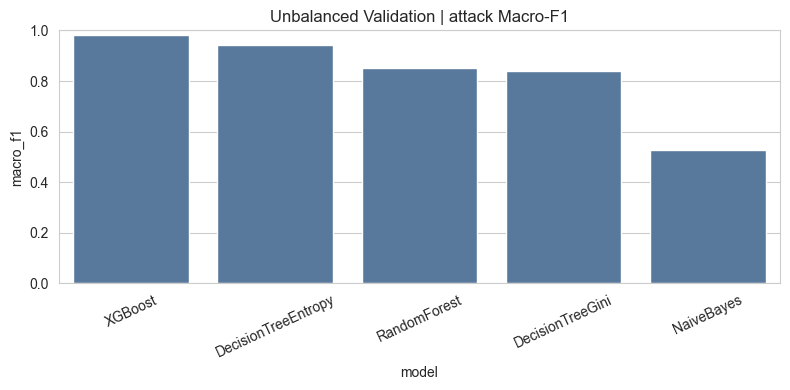

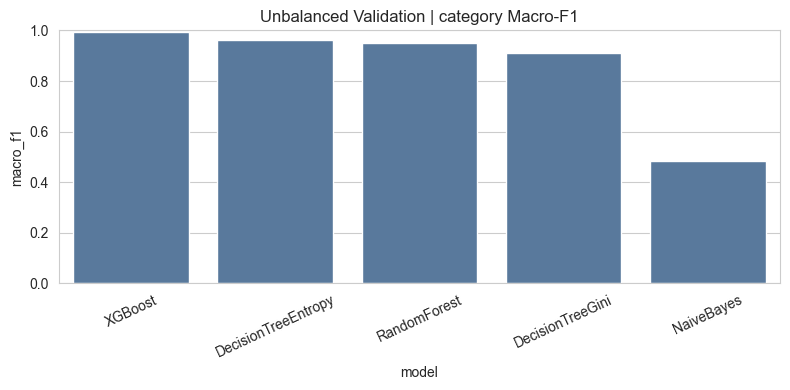

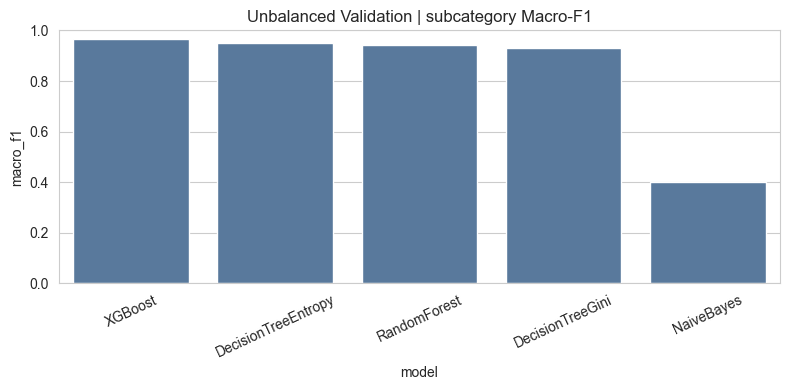

Unbalanced Validation 各目標最佳模型： {'attack': 'XGBoost', 'category': 'XGBoost', 'subcategory': 'XGBoost'}


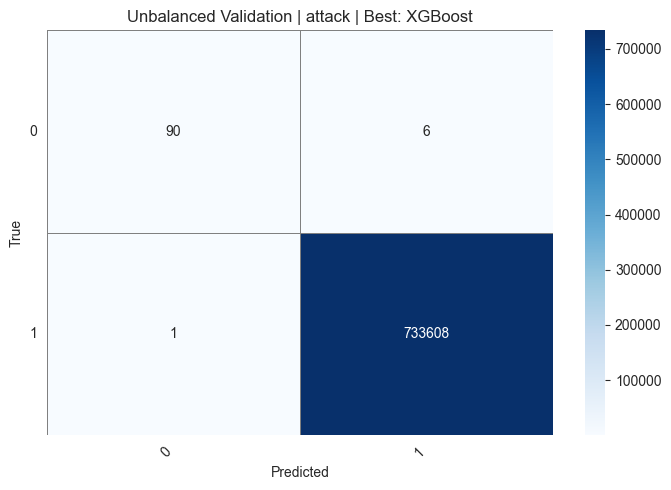

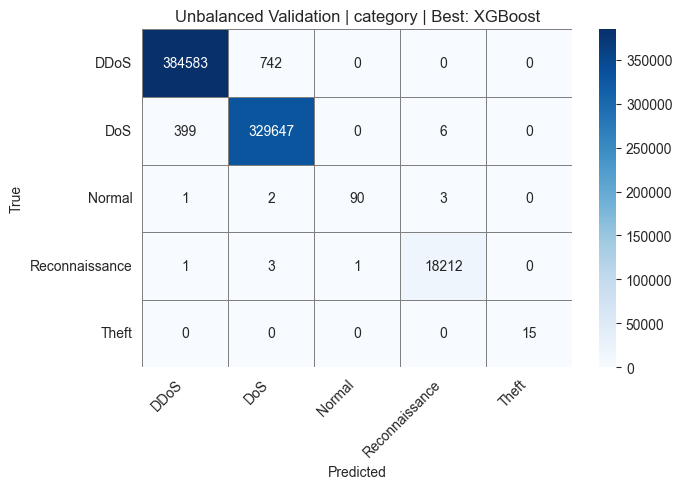

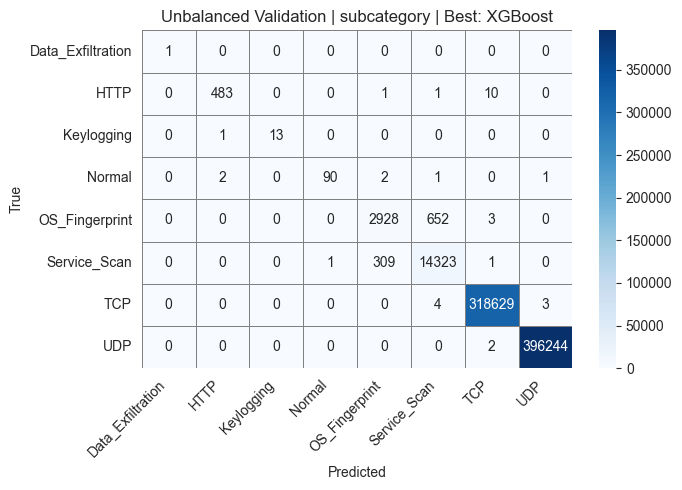

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model
12,attack,0.999993,0.984209,0.986771,0.999993,XGBoost
6,attack,0.999973,0.952624,0.947910,0.999973,DecisionTreeEntropy
9,attack,0.999948,0.889462,0.897837,0.999948,DecisionTreeGini
0,attack,0.999943,0.784210,0.859986,0.999935,RandomForest
3,attack,0.996281,0.956040,0.529037,0.998015,NaiveBayes
13,category,0.998412,0.992983,0.987911,0.998412,XGBoost
1,category,0.994708,0.928341,0.957012,0.994704,RandomForest
10,category,0.989061,0.940448,0.954763,0.989060,DecisionTreeGini
7,category,0.989541,0.978954,0.952649,0.989548,DecisionTreeEntropy
4,category,0.705770,0.587119,0.468235,0.681178,NaiveBayes


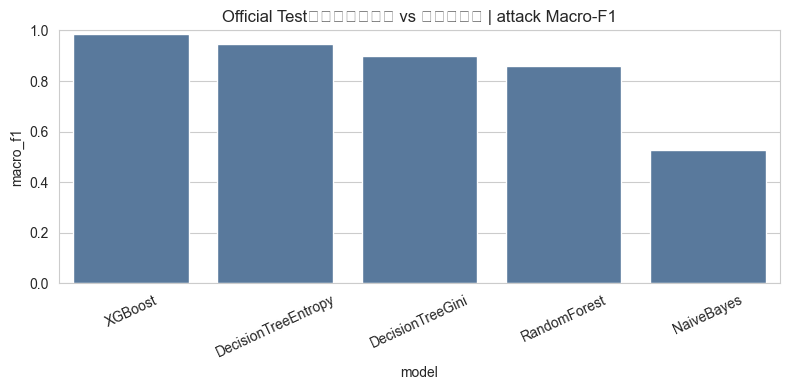

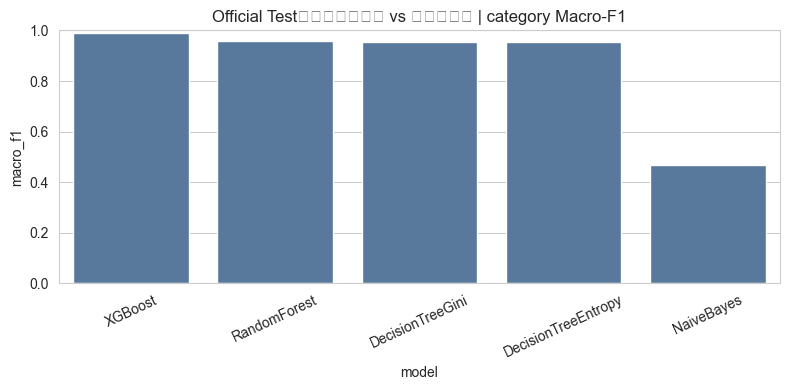

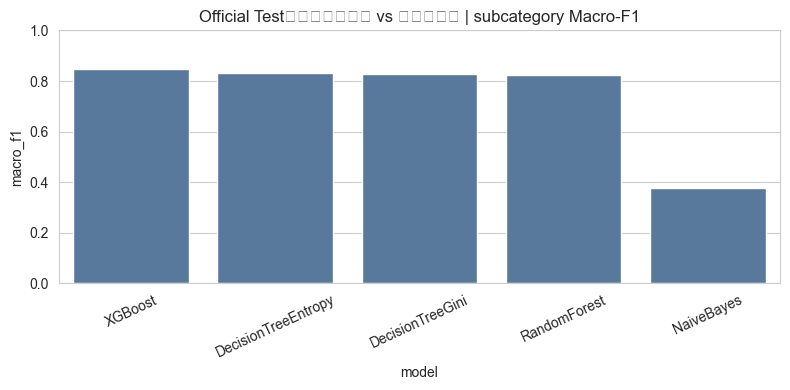

Official Test｜訓練好的模型 vs 官方測試集 各目標最佳模型： {'attack': 'XGBoost', 'category': 'XGBoost', 'subcategory': 'XGBoost'}


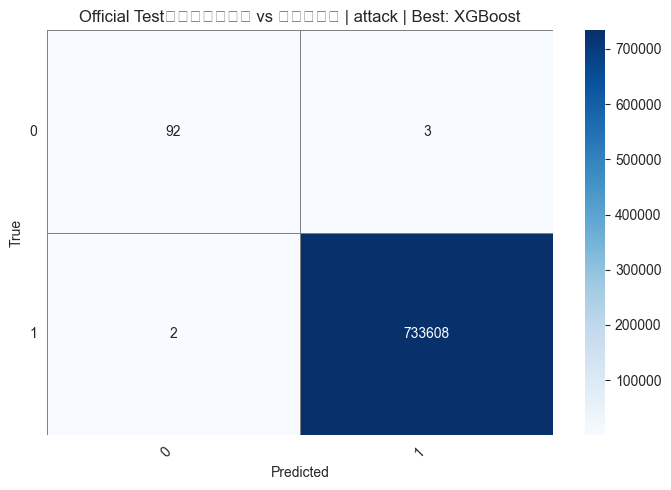

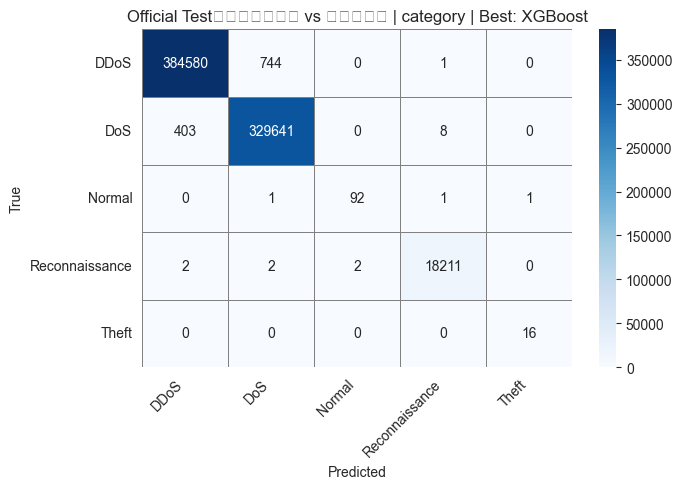

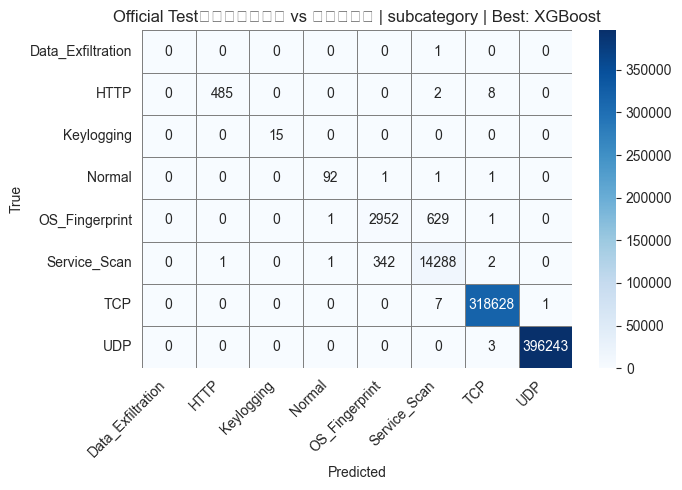

,target,model,validation_macro_f1,test_macro_f1,差距
6,attack,DecisionTreeEntropy,0.942098,0.947910,-0.0058
9,attack,DecisionTreeGini,0.839163,0.897837,-0.0587
3,attack,NaiveBayes,0.527000,0.529037,-0.0020
0,attack,RandomForest,0.851336,0.859986,-0.0086
12,attack,XGBoost,0.981281,0.986771,-0.0055
7,category,DecisionTreeEntropy,0.961094,0.952649,0.0084
10,category,DecisionTreeGini,0.911211,0.954763,-0.0436
4,category,NaiveBayes,0.485424,0.468235,0.0172
1,category,RandomForest,0.949234,0.957012,-0.0078
13,category,XGBoost,0.991791,0.987911,0.0039


In [21]:
unbalanced_metrics_df = pd.concat([v["metrics"] for v in chain_results.values()], ignore_index=True)
display(unbalanced_metrics_df.sort_values(["target", "macro_f1"], ascending=[True, False]))

show_metric_bars(unbalanced_metrics_df, "Unbalanced Validation")
show_confusion_matrices(chain_results, y_valid, "Unbalanced Validation")

for name, v in chain_test_results.items():
    preds = v["preds"]
    rows = []
    for target_col in TARGET_COLUMNS:
        row = evaluate_predictions(y_test_official, pd.DataFrame(preds) if not isinstance(preds, pd.DataFrame) else preds, target_col)
        row["model"] = name
        rows.append(row)
    chain_test_results[name]["metrics"] = pd.DataFrame(rows)

test_metrics_df = pd.concat([v["metrics"] for v in chain_test_results.values()], ignore_index=True)
display(test_metrics_df.sort_values(["target", "macro_f1"], ascending=[True, False]))

show_metric_bars(test_metrics_df, "Official Test｜訓練好的模型 vs 官方測試集")
show_confusion_matrices(chain_test_results, y_test_official, "Official Test｜訓練好的模型 vs 官方測試集")

# 對比表
comparison = pd.merge(
    unbalanced_metrics_df[["target","model","macro_f1"]].rename(columns={"macro_f1":"validation_macro_f1"}),
    test_metrics_df[["target","model","macro_f1"]].rename(columns={"macro_f1":"test_macro_f1"}),
    on=["target","model"]
)
comparison["差距"] = (comparison["validation_macro_f1"] - comparison["test_macro_f1"]).round(4)
display(comparison.sort_values(["target","model"]))